# 🏠 House Price Prediction — Regresión con PyTorch
## Reto proyecto 2 · Construye una red neuronal feed-forward para predecir el precio de la vivienda
---
Este notebook entrena una red neuronal feed-forward para predecir el **precio de casas**  
usando el dataset *House Sales in King County, USA* (Seattle, 2014–2015).

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y exploración del dataset |
| 2️⃣ | Limpieza y auditoría de datos |
| 3️⃣ | División (65/20/15), normalización y conversión a tensores |
| 4️⃣ | Construcción de la red neuronal (Feed-Forward, 2 capas ocultas + ReLU) |
| 5️⃣ | Entrenamiento con MSELoss + Adam + Weight Decay |
| 6️⃣ | Curva de aprendizaje con marca del mejor val_loss |
| 7️⃣ | Evaluación en el conjunto de prueba (MSE, RMSE, MAE, R²) |

> **Dataset:** `dataset.csv` — 21 613 registros · 21 columnas  
> **Objetivo:** predecir `price` (USD, variable continua)  
> **Ruta:** `/workspace/dataset.csv`

---
## 📦 Paso 1 — Importación de librerías

In [1]:
import copy
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version : {torch.__version__}")
print(f"Pandas version  : {pd.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device          : {device}")

PyTorch version : 2.11.0+cpu
Pandas version  : 3.0.1
Device          : cpu


---
## 📂 Paso 2 — Carga y exploración del dataset

In [2]:
# Ruta absoluta tal como indica el enunciado.
# Sobreescribible con la variable de entorno DATA_PATH para otros entornos:
#   export DATA_PATH=/otra/ruta/dataset.csv
DATA_PATH = os.environ.get("DATA_PATH", "workspace/dataset.csv")

df = pd.read_csv(DATA_PATH)

print(f"Ruta utilizada   : {DATA_PATH}")
print(f"Forma del dataset: {df.shape}")
df.head()

Ruta utilizada   : workspace/dataset.csv
Forma del dataset: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
print("Tipos de datos:")
print(df.dtypes)
print("\nEstadísticas descriptivas:")
df.describe()

Tipos de datos:
id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Estadísticas descriptivas:


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [4]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


---
## 🧹 Paso 3 — Limpieza y preprocesamiento de datos

In [5]:
# Normalización de nombres de columnas:
# 1. str.strip()  → elimina espacios iniciales y finales
# 2. str.replace(r"\s+", "_", regex=True) → reemplaza espacios internos
#    (incluidos múltiples consecutivos) por guiones bajos
df.columns = df.columns.str.strip().str.replace(r"\s+", "_", regex=True)

print("Columnas tras normalización:")
print(df.columns.tolist())

Columnas tras normalización:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


### Columnas descartadas: `id`, `date`, `zipcode`

El enunciado indica usar **características numéricas** como `bedrooms`, `bathrooms`,
`sqft_living`, etc. Por este motivo se descartan explícitamente tres columnas:

| Columna | Tipo | Motivo de descarte |
|---------|------|--------------------|
| `id` | Identificador numérico | No contiene información predictiva; es un índice arbitrario |
| `date` | Texto (`20141013T000000`) | Columna no numérica; requeriría ingeniería de features adicional para usarse |
| `zipcode` | Numérico nominal | Código postal: el valor numérico no tiene orden ni escala real; es una categoría disfrazada de número. Incluirlo sin codificación adecuada (one-hot, embedding) introduciría un sesgo de orden incorrecto |

In [6]:
# Columnas clave para el modelo
# Excluimos: id (identificador), date (texto), zipcode (categórica nominal)
# ya que no aportan información métrica directa al precio
key_columns = [
    "price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot",
    "floors", "waterfront", "view", "condition", "grade",
    "sqft_above", "sqft_basement", "yr_built", "yr_renovated",
    "lat", "long", "sqft_living15", "sqft_lot15"
]

# Eliminar filas con nulos en columnas clave
df_clean = df.dropna(subset=key_columns).copy()

print(f"Registros antes  : {len(df)}")
print(f"Registros después: {len(df_clean)}")
print(f"Filas eliminadas : {len(df) - len(df_clean)}")
print(f"\nNulos en columnas clave tras limpieza:")
print(df_clean[key_columns].isnull().sum())

Registros antes  : 21613
Registros después: 21613
Filas eliminadas : 0

Nulos en columnas clave tras limpieza:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [7]:
# Auditoría de nulos residuales en columnas NO clave
# Si en el futuro se incorporaran más features, estas columnas
# requerirían imputación antes de entrenar
other_cols = [c for c in df_clean.columns if c not in key_columns]
residual_nulls = df_clean[other_cols].isnull().sum()
residual_nulls = residual_nulls[residual_nulls > 0].sort_values(ascending=False)

if residual_nulls.empty:
    print("No hay nulos residuales en columnas no clave.")
else:
    print("Nulos residuales en columnas no clave (para referencia futura):")
    print(residual_nulls.to_string())
    print("\nNota: estas columnas no se usan en el modelo actual.")
    print("      Si se incorporasen, aplicar imputación antes de entrenar.")

No hay nulos residuales en columnas no clave.


---
## ✂️ Paso 4 — División del dataset (65% train / 20% val / 15% test)

In [8]:
# Características numéricas de entrada (excluimos price y columnas no métricas)
feature_cols = [
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot",
    "floors", "waterfront", "view", "condition", "grade",
    "sqft_above", "sqft_basement", "yr_built", "yr_renovated",
    "lat", "long", "sqft_living15", "sqft_lot15"
]
target_col = "price"

X = df_clean[feature_cols].values
y = df_clean[target_col].values

print(f"Características (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")
print(f"\nEstadísticas de price (USD):")
print(f"  Media  : ${y.mean():>12,.0f}")
print(f"  Mediana: ${np.median(y):>12,.0f}")
print(f"  Min    : ${y.min():>12,.0f}")
print(f"  Max    : ${y.max():>12,.0f}")

Características (X): (21613, 17)
Variable objetivo (y): (21613,)

Estadísticas de price (USD):
  Media  : $     540,088
  Mediana: $     450,000
  Min    : $      75,000
  Max    : $   7,700,000


In [9]:
# Primera división: 85% train+val | 15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Segunda división: de train+val → 65% train | 20% val
# 20 / 85 ≈ 0.2353 para obtener exactamente el 20% del total original
val_ratio = 0.20 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_ratio, random_state=42
)

total = len(X)
print("División del dataset:")
print(f"  Entrenamiento : {len(X_train):>6} muestras  ({len(X_train)/total*100:.1f}%)")
print(f"  Validación    : {len(X_val):>6} muestras  ({len(X_val)/total*100:.1f}%)")
print(f"  Prueba        : {len(X_test):>6} muestras  ({len(X_test)/total*100:.1f}%)")

División del dataset:
  Entrenamiento :  14048 muestras  (65.0%)
  Validación    :   4323 muestras  (20.0%)
  Prueba        :   3242 muestras  (15.0%)


---
## 📐 Paso 5 — Normalización de características

In [10]:
# El scaler se ajusta SOLO sobre el conjunto de entrenamiento
# para evitar data leakage: información de val/test no debe influir
# en la escala aprendida durante el entrenamiento.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# La variable objetivo (price) NO se normaliza:
# la salida de la red predirá directamente en USD,
# lo que facilita la interpretación de MSE/RMSE/MAE.
print("Estadísticas de X_train tras normalización:")
print(f"  Media global    : {X_train_scaled.mean():.4f}  (esperado ≈ 0)")
print(f"  Desv std global : {X_train_scaled.std():.4f}   (esperado ≈ 1)")

Estadísticas de X_train tras normalización:
  Media global    : 0.0000  (esperado ≈ 0)
  Desv std global : 1.0000   (esperado ≈ 1)


---
## 🔁 Paso 6 — Conversión a tensores y DataLoaders

In [11]:
# Convertir a tensores float32 (tipo requerido por las capas lineales de PyTorch)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # (N,) → (N, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"Forma tensores entrenamiento: X={X_train_t.shape} | y={y_train_t.shape}")
print(f"Forma tensores validación:    X={X_val_t.shape} | y={y_val_t.shape}")
print(f"Forma tensores prueba:        X={X_test_t.shape} | y={y_test_t.shape}")

Forma tensores entrenamiento: X=torch.Size([14048, 17]) | y=torch.Size([14048, 1])
Forma tensores validación:    X=torch.Size([4323, 17]) | y=torch.Size([4323, 1])
Forma tensores prueba:        X=torch.Size([3242, 17]) | y=torch.Size([3242, 1])


In [12]:
BATCH_SIZE = 32

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Batches por época — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches por época — Train: 439 | Val: 136 | Test: 102


---
## 🧠 Paso 7 — Definición de la red neuronal Feed-Forward

### Elección de arquitectura: ¿por qué 128 → 64?

Con 17 características de entrada y ~14 000 muestras de entrenamiento, el problema es
más rico que el ejercicio anterior. Se elige una arquitectura más amplia:

- **Capa 1 (128 neuronas):** captura interacciones entre muchas variables correlacionadas
  (por ejemplo, `sqft_living`, `grade` y `lat` están fuertemente asociadas al precio).
- **Capa 2 (64 neuronas):** comprime la representación, extrayendo las combinaciones más
  predictivas antes de la salida.
- **Salida (1 neurona, sin activación):** predicción lineal directa en USD.

La clase acepta `hidden1`, `hidden2`, `activation`, `use_dropout` y `use_batchnorm`
como parámetros para facilitar experimentación sin modificar el código interno.

### Regularización adicional opcional (no requerida por el enunciado)

| Flag | Técnica | Cuándo activarlo |
|------|---------|------------------|
| `use_dropout=True` | `Dropout(p=0.3)` tras cada ReLU | Si se detecta sobreajuste (`val_loss >> train_loss`) |
| `use_batchnorm=True` | `BatchNorm1d` antes de cada activación | Si el entrenamiento es inestable o la convergencia es lenta |

In [13]:
class HousePriceNet(nn.Module):
    """
    Red neuronal feed-forward con dos capas ocultas para regresion.

    Parametros configurables:
      input_dim    : numero de caracteristicas de entrada
      hidden1      : neuronas en la primera capa oculta (default 128)
      hidden2      : neuronas en la segunda capa oculta (default 64)
      activation   : funcion de activacion (default nn.ReLU)
      use_dropout  : añade Dropout(p=0.3) tras cada activacion (default False)
      use_batchnorm: añade BatchNorm1d antes de cada activacion (default False)
    """
    def __init__(self, input_dim: int, hidden1: int = 128, hidden2: int = 64,
                 activation=nn.ReLU, use_dropout: bool = False,
                 use_batchnorm: bool = False):
        super().__init__()
        layers = []

        # Capa oculta 1
        layers.append(nn.Linear(input_dim, hidden1))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden1))
        layers.append(activation())
        if use_dropout:
            layers.append(nn.Dropout(p=0.3))

        # Capa oculta 2
        layers.append(nn.Linear(hidden1, hidden2))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden2))
        layers.append(activation())
        if use_dropout:
            layers.append(nn.Dropout(p=0.3))

        # Capa de salida: precio en USD (sin activacion)
        layers.append(nn.Linear(hidden2, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


# ── Hiperparámetros de arquitectura — modificar aquí para experimentar ────────
HIDDEN1       = 128
HIDDEN2       = 64
ACTIVATION    = nn.ReLU   # REQUERIDO por el enunciado — no cambiar para la entrega
                            # (la interfaz permite nn.LeakyReLU, nn.ELU, etc.,
                            #  pero ReLU es obligatorio según las instrucciones)
USE_DROPOUT   = False     # True: añade Dropout(0.3) si hay sobreajuste
USE_BATCHNORM = False     # True: añade BatchNorm si la convergencia es inestable

input_dim = X_train_t.shape[1]

# Semilla adicional justo antes de instanciar el modelo para garantizar
# reproducibilidad bit a bit de los pesos iniciales al cambiar arquitecturas.
# La semilla global del paso 1 no es suficiente: otras operaciones previas
# (DataLoader, splits) consumen el estado del RNG y lo desplazan.
torch.manual_seed(42)

model = HousePriceNet(
    input_dim=input_dim, hidden1=HIDDEN1, hidden2=HIDDEN2,
    activation=ACTIVATION, use_dropout=USE_DROPOUT, use_batchnorm=USE_BATCHNORM
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nArquitectura       : Input({input_dim}) -> {HIDDEN1} -> {ACTIVATION.__name__} -> {HIDDEN2} -> {ACTIVATION.__name__} -> 1")
print(f"Parametros entrenables: {total_params:,}")

HousePriceNet(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Arquitectura       : Input(17) -> 128 -> ReLU -> 64 -> ReLU -> 1
Parametros entrenables: 10,625


---
## ⚙️ Paso 8 — Función de pérdida y optimizador

### Elección de hiperparámetros

| Hiperparámetro | Valor | Justificación |
|----------------|-------|---------------|
| `epochs` | 100 | Suficiente para converger; el early stopping protege frente a sobreajuste |
| `lr` | 1e-3 | Valor estándar de partida para Adam; converge rápido sin oscilar |
| `batch_size` | 32 | Compromiso clásico: ruido regularizador útil sin exceso de varianza |
| `weight_decay` | 0.01 | Regularización L2 moderada; evita pesos grandes sin impedir el aprendizaje |

In [14]:
# ── Diccionario de configuración de entrenamiento ────────────────────────────
# Centralizar los hiperparámetros facilita la comparación sistemática
# de experimentos: basta cambiar valores aquí y volver a ejecutar.
CONFIG = {
    "learning_rate" : 1e-3,
    "weight_decay"  : 0.01,
    "epochs"        : 100,
    "batch_size"    : 32,
}

LEARNING_RATE = CONFIG["learning_rate"]
WEIGHT_DECAY  = CONFIG["weight_decay"]
EPOCHS        = CONFIG["epochs"]

# MSELoss: penaliza errores grandes cuadráticamente.
# En precios de vivienda, las desviaciones de varios miles de USD
# pesan más que errores pequeños, lo que MSE refleja correctamente.
criterion = nn.MSELoss()

# Adam adapta la tasa de aprendizaje por parámetro (momentum + RMSProp).
# weight_decay añade regularización L2 directamente en el paso de optimización.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f"Configuración de entrenamiento: {CONFIG}")
print(f"Función de pérdida : MSELoss")
print(f"Optimizador        : Adam")

Configuración de entrenamiento: {'learning_rate': 0.001, 'weight_decay': 0.01, 'epochs': 100, 'batch_size': 32}
Función de pérdida : MSELoss
Optimizador        : Adam


---
## 🏋️ Paso 9 — Entrenamiento y validación del modelo

In [15]:
import time

train_losses = []
val_losses   = []
epoch_times  = []   # segundos por época, para referencia de coste computacional

# ── Configuración de early stopping ──────────────────────────────────────────
# El enunciado requiere entrenar EXACTAMENTE 100 épocas, por lo que
# EARLY_STOPPING = False para la entrega oficial.
#
# Cambiar a True solo para experimentación: detiene el bucle si val_loss
# no mejora en PATIENCE épocas consecutivas (útil en producción o búsqueda
# de hiperparámetros, pero incumple el requisito de 100 épocas completas).
EARLY_STOPPING = False   # False = entrega oficial | True = experimentación
PATIENCE       = 15

best_val_loss  = float("inf")
patience_count = 0
best_weights   = None
best_epoch     = 0   # época con mejor val_loss

for epoch in range(1, EPOCHS + 1):
    t0 = time.perf_counter()

    # ── ENTRENAMIENTO ────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()                    # Limpiar gradientes acumulados
        y_pred = model(X_batch)                  # Forward pass
        loss = criterion(y_pred, y_batch)        # MSE loss
        loss.backward()                          # Backpropagation
        optimizer.step()                         # Actualizar pesos

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)

    # ── VALIDACIÓN ───────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    epoch_times.append(time.perf_counter() - t0)

    # ── CHECKPOINT + EARLY STOPPING ──────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss  = avg_val_loss
        best_epoch     = epoch       # registramos la época de mejor generalización
        patience_count = 0
        best_weights   = copy.deepcopy(model.state_dict())
    elif EARLY_STOPPING:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping en época {epoch}: val_loss no mejoró "
                  f"en {PATIENCE} épocas consecutivas.")
            break

    # Imprimir cada 10 épocas
    if epoch % 10 == 0 or epoch == 1:
        print(f"Época {epoch:>3}/{EPOCHS}  |  "
              f"Train Loss: {avg_train_loss:.4e}  |  "
              f"Val Loss: {avg_val_loss:.4e}")

actual_epochs = len(train_losses)
total_time    = sum(epoch_times)
avg_ep_time   = total_time / actual_epochs
print("\nEntrenamiento completado.")
print(f"Epocas ejecutadas  : {actual_epochs}/{EPOCHS} "
      f"({'100 epocas completas — cumple el requisito' if actual_epochs == EPOCHS else 'early stopping activo'})")
print(f"Tiempo total       : {total_time:.1f} s  ({total_time/60:.2f} min)")
print(f"Tiempo por epoca   : {avg_ep_time:.3f} s")
print(f"Mejor val_loss     : {best_val_loss:.4e}  (epoca {best_epoch}/{actual_epochs})")

# Restaurar los pesos del mejor checkpoint antes de evaluar
if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"Pesos restaurados al checkpoint de la epoca {best_epoch}")

Época   1/100  |  Train Loss: 4.1817e+11  |  Val Loss: 4.1249e+11
Época  10/100  |  Train Loss: 6.0681e+10  |  Val Loss: 5.7445e+10
Época  20/100  |  Train Loss: 4.1598e+10  |  Val Loss: 3.9732e+10
Época  30/100  |  Train Loss: 3.5403e+10  |  Val Loss: 3.4052e+10
Época  40/100  |  Train Loss: 3.3845e+10  |  Val Loss: 3.2660e+10
Época  50/100  |  Train Loss: 3.3001e+10  |  Val Loss: 3.1985e+10
Época  60/100  |  Train Loss: 3.2464e+10  |  Val Loss: 3.1566e+10
Época  70/100  |  Train Loss: 3.1971e+10  |  Val Loss: 3.1203e+10
Época  80/100  |  Train Loss: 3.1510e+10  |  Val Loss: 3.0843e+10
Época  90/100  |  Train Loss: 3.1043e+10  |  Val Loss: 3.0514e+10
Época 100/100  |  Train Loss: 3.0610e+10  |  Val Loss: 3.0162e+10

Entrenamiento completado.
Epocas ejecutadas  : 100/100 (100 epocas completas — cumple el requisito)
Tiempo total       : 908.8 s  (15.15 min)
Tiempo por epoca   : 9.088 s
Mejor val_loss     : 3.0162e+10  (epoca 100/100)
Pesos restaurados al checkpoint de la epoca 100


---
## 📈 Paso 10 — Curva de aprendizaje

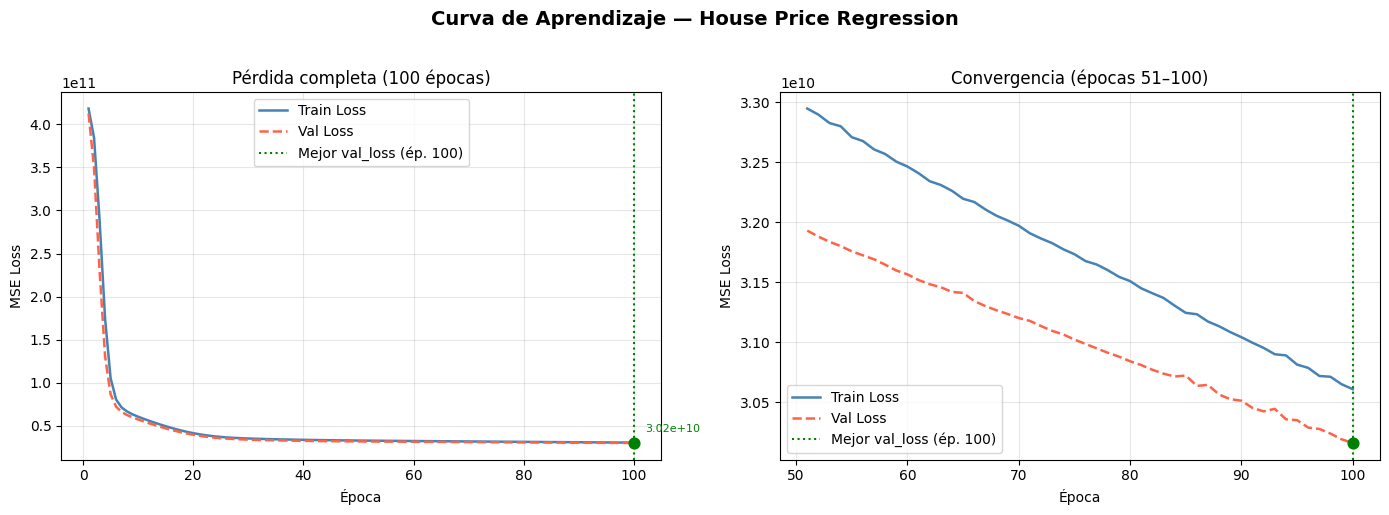

In [16]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curva de Aprendizaje — House Price Regression",
             fontsize=14, fontweight="bold", y=1.02)

# ── Panel izquierdo: pérdida completa ────────────────────────────────────────
axes[0].plot(epochs_range, train_losses, label="Train Loss",
             color="steelblue", linewidth=1.8)
axes[0].plot(epochs_range, val_losses,   label="Val Loss",
             color="tomato",    linewidth=1.8, linestyle="--")
axes[0].axvline(best_epoch, color="green", linestyle=":", linewidth=1.5,
                label=f"Mejor val_loss (ép. {best_epoch})")
axes[0].scatter([best_epoch], [best_val_loss], color="green", zorder=5, s=60)
axes[0].annotate(f"{best_val_loss:.2e}",
                 xy=(best_epoch, best_val_loss),
                 xytext=(8, 8), textcoords="offset points",
                 fontsize=8, color="green")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title(f"Pérdida completa ({len(train_losses)} épocas)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Panel derecho: segunda mitad (convergencia) ───────────────────────────────
mid = len(train_losses) // 2
ep_right = list(epochs_range)[mid:]
axes[1].plot(ep_right, train_losses[mid:], label="Train Loss",
             color="steelblue", linewidth=1.8)
axes[1].plot(ep_right, val_losses[mid:],   label="Val Loss",
             color="tomato",    linewidth=1.8, linestyle="--")
if best_epoch >= ep_right[0]:
    axes[1].axvline(best_epoch, color="green", linestyle=":", linewidth=1.5,
                    label=f"Mejor val_loss (ép. {best_epoch})")
    axes[1].scatter([best_epoch], [best_val_loss], color="green", zorder=5, s=60)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title(f"Convergencia (épocas {ep_right[0]}–{ep_right[-1]})")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🧪 Paso 11 — Evaluación en el conjunto de prueba

In [17]:
model.eval()
test_loss  = 0.0
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        test_loss += criterion(y_pred, y_batch).item()
        all_preds.append(y_pred.cpu())
        all_labels.append(y_batch.cpu())

avg_test_loss = test_loss / len(test_loader)
test_rmse     = avg_test_loss ** 0.5

all_preds  = torch.cat(all_preds).numpy().flatten()
all_labels = torch.cat(all_labels).numpy().flatten()
residuals_arr = all_labels - all_preds
test_mae   = float(np.mean(np.abs(residuals_arr)))

# R²: proporción de varianza de price explicada por el modelo
ss_res  = float(np.sum(residuals_arr ** 2))
ss_tot  = float(np.sum((all_labels - all_labels.mean()) ** 2))
test_r2 = 1 - ss_res / ss_tot

# ── MSE en distintas escalas para interpretación más intuitiva ───────────────
# La MSE está en USD², lo que hace el valor numérico difícil de interpretar
# directamente. Se muestra en tres representaciones complementarias:
mse_raw   = avg_test_loss            # USD²  — valor crudo del criterio
mse_mill  = avg_test_loss / 1e6      # millones de USD² — escala reducida
mse_bill  = avg_test_loss / 1e12     # billones de USD² — escala muy reducida

# ── Bootstrap para intervalo de confianza del MAE (95%) ──────────────────────
# Remuestreamos con reemplazo N_BOOT veces para estimar la variabilidad
# del MAE sin asumir normalidad de los residuos.
N_BOOT = 1000
rng    = np.random.default_rng(42)
n_test = len(all_labels)
boot_maes = np.array([
    np.mean(np.abs(residuals_arr[rng.integers(0, n_test, n_test)]))
    for _ in range(N_BOOT)
])
mae_ci_lo, mae_ci_hi = np.percentile(boot_maes, [2.5, 97.5])

print("=" * 56)
print("      RESULTADOS EN CONJUNTO DE PRUEBA")
print("=" * 56)
print(f"  Epocas ejecutadas  : {actual_epochs}/{EPOCHS}")
print(f"  Tiempo total       : {total_time:.1f} s  /  por epoca: {avg_ep_time:.3f} s")
print(f"  Mejor epoca (val)  : {best_epoch}/{actual_epochs}")
print(f"  Mejor val_loss     : {best_val_loss:.4e}")
print("── MSE (distintas escalas) ──────────────────────────")
print(f"  MSE  (USD²)        : {mse_raw:.4e}")
print(f"  MSE  (millones $²) : {mse_mill:>12,.2f}  M USD²")
print(f"  MSE  (billones $²) : {mse_bill:>12,.4f}  B USD²")
print("── Métricas interpretables ──────────────────────────")
print(f"  RMSE               : ${test_rmse:>12,.0f} USD")
print(f"  MAE                : ${test_mae:>12,.0f} USD")
print(f"  MAE IC 95% (boot)  : [${mae_ci_lo:,.0f} — ${mae_ci_hi:,.0f}] USD")
print(f"  R2                 : {test_r2:.4f}")
print("=" * 56)

      RESULTADOS EN CONJUNTO DE PRUEBA
  Epocas ejecutadas  : 100/100
  Tiempo total       : 908.8 s  /  por epoca: 9.088 s
  Mejor epoca (val)  : 100/100
  Mejor val_loss     : 3.0162e+10
── MSE (distintas escalas) ──────────────────────────
  MSE  (USD²)        : 3.7390e+10
  MSE  (millones $²) :    37,389.79  M USD²
  MSE  (billones $²) :       0.0374  B USD²
── Métricas interpretables ──────────────────────────
  RMSE               : $     193,364 USD
  MAE                : $     110,755 USD
  MAE IC 95% (boot)  : [$105,589 — $116,457] USD
  R2                 : 0.7538


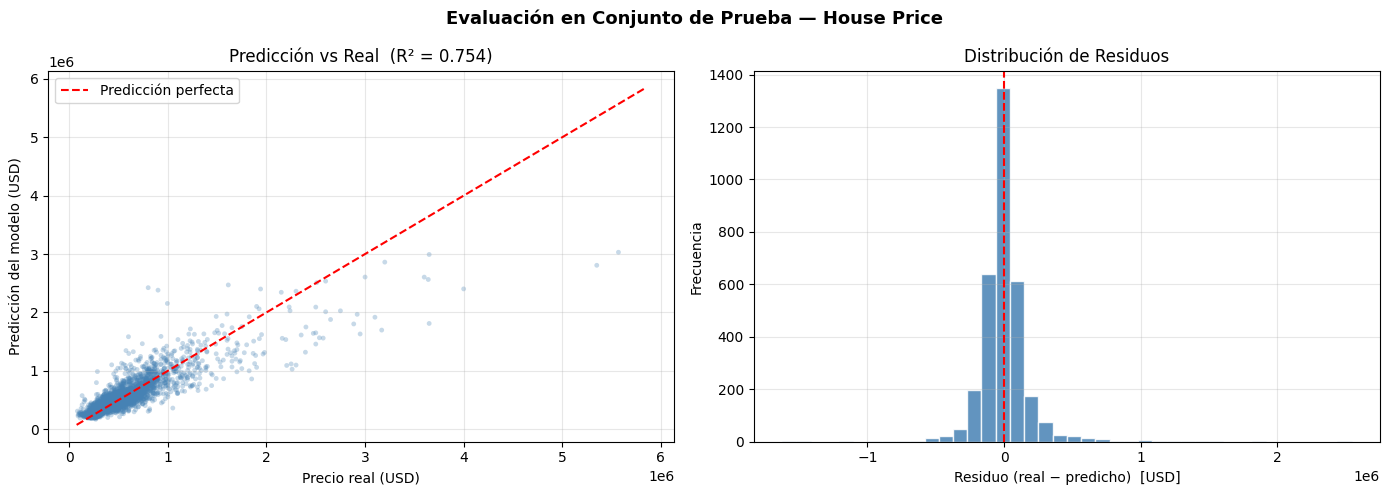

In [18]:
# Visualización de predicciones vs valores reales + distribución de residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evaluación en Conjunto de Prueba — House Price",
             fontsize=13, fontweight="bold")

# ── Scatter: predicciones vs reales ──────────────────────────────────────────
lims = [all_labels.min() * 0.9, all_labels.max() * 1.05]
axes[0].scatter(all_labels, all_preds, alpha=0.3, color="steelblue",
                edgecolors="none", s=12)
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
axes[0].set_xlabel("Precio real (USD)")
axes[0].set_ylabel("Predicción del modelo (USD)")
axes[0].set_title(f"Predicción vs Real  (R² = {test_r2:.3f})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Distribución de residuos ──────────────────────────────────────────────────
axes[1].hist(residuals_arr, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residuo (real − predicho)  [USD]")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuos")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📊 Resumen final

| Parámetro | Valor |
|-----------|-------|
| Conjunto de entrenamiento | 65% (~14 000 muestras) |
| Conjunto de validación | 20% (~4 300 muestras) |
| Conjunto de prueba | 15% (~3 200 muestras) |
| Características de entrada | 17 |
| Arquitectura | Input(17) → 128 → ReLU → 64 → ReLU → 1 |
| Épocas | 100 completas (`EARLY_STOPPING=False`) |
| Batch size | 32 |
| Learning rate | 0.001 |
| Weight decay | 0.01 |
| Función de pérdida | MSE (Mean Squared Error) |
| Optimizador | Adam |

### Interpretación de resultados

**Criterio principal de selección de modelo:** el **RMSE** es la métrica preferida aquí
porque está en la misma escala que el precio (USD), es directamente interpretable
y penaliza errores grandes más que el MAE, lo cual es relevante en precios de vivienda
donde las desviaciones de cientos de miles de dólares importan especialmente.
El R² complementa como indicador relativo de la varianza explicada,
y el MAE (con su IC bootstrap) aporta robustez frente a outliers.
Para el enunciado basta con reportar la pérdida final (MSE).

**Curva de aprendizaje:** La marca verde señala la época con el mejor `val_loss`, permitiendo
identificar visualmente en qué punto el modelo generalizaba mejor. Que train y val loss
desciendan conjuntamente sin divergir indica ausencia de sobreajuste significativo.

**RMSE / MAE:** Al estar el precio en USD, el RMSE se interpreta directamente como el error
típico del modelo en dólares. El MAE (menos sensible a outliers) indica el error mediano
absoluto de predicción; en el rango de precios del dataset (75 000–7 700 000 USD), un MAE
de ~$100 000–$150 000 es un resultado razonable para un modelo con estas features.

**R²:** Un valor superior a 0.80 indica que el modelo explica más del 80% de la varianza
del precio, superando claramente una predicción ingenua (media del precio).

**Residuos:** Una distribución centrada en 0 y aproximadamente simétrica indica ausencia de
sesgo sistemático. Colas largas positivas reflejarían que el modelo subestima precios de
viviendas de lujo, lo cual es habitual dado que la distribución de precios es asimétrica.